In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

In [2]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]

# Aggregating
df = (
    df.groupby("timestamp")["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [ ]:
alpha = 0.999
T = 35000

l_agg = df['out.electricity.net.energy_consumption'][0:T].values
tstamps = df['timestamp'][0:T].values

lhat = np.sin(np.arange(T)/100) + 1
p0 = 150   # transformer limit in MW

K = round((1-alpha)*T)
c_res = p0 - l_agg

# Dynamic hosting capacity
c_dyn = np.full(T, np.inf)
active = lhat > 1e-12 # to avoid division by zero;
active_idx = np.flatnonzero(active)

c_dyn[active] = c_res[active] / lhat[active]

# Sort active slots by dynamic hosting capacity
sorted_active_local = np.argsort(c_dyn[active])          # indices within active subset
sorted_active_global = active_idx[sorted_active_local]   # map back to original timeline

# (K+1)-th smallest dynamic hosting capacity
C_k = c_dyn[sorted_active_global[K]]

# Intervene at the K slots of lowest dynamic hosting capacity
intervention_idx = sorted_active_global[:K]

u = np.zeros(T, dtype=float)
u[intervention_idx] = c_res[intervention_idx] - C_k * lhat[intervention_idx]


epsilon = 0

# Decision Variables
C = cp.Variable(name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, name="s")
u_CVaR = cp.Variable(T,name="u_CVaR")
t = cp.Variable(T,name="t")

eta_old = 0

# # c_res = p0 - l_agg
iters = 10
C_iters = np.zeros(iters)
u_CVaRs = np.zeros((iters,T))

for k in range(iters):

    eta_prev = eta_old

    constraints = [
        C*lhat - u_CVaR + l_agg <= p0-eta_old,
        eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
        u_CVaR- eta <= s,
        0<= u_CVaR - eta,
        0<=s
    ]

    # obj = cp.Maximize(C)
    obj = cp.Minimize(-C)
    problem = cp.Problem(obj, constraints)

    problem.solve(solver="ECOS", verbose=False)

    print("Optimal C:", C.value)
    print("C_K",C_k)

    C_iters[k] = C.value

    # eta_old = eta.value*0.2 + eta_old*0.8
    eta_old = eta.value

    u_CVaRs[k] = u_CVaR.value

plt.plot(C_iters)
plt.plot(np.ones_like(C_iters)*C_k)    

c:\Users\gcsar\anaconda3\envs\RL\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Optimal C: 6.451021452083977
C_K 23.936730183958666
Optimal C: 31.057095150627635
C_K 23.936730183958666
Optimal C: 13.312235774678278
C_K 23.936730183958666
Optimal C: 30.605910939816233
C_K 23.936730183958666
Optimal C: 31.016486585905238
C_K 23.936730183958666
Optimal C: 10.402108433634107
C_K 23.936730183958666
Optimal C: 33.840795713459386
C_K 23.936730183958666
Optimal C: 27.14965548542335
C_K 23.936730183958666
Optimal C: 12.483025133324345
C_K 23.936730183958666
Optimal C: 33.666807113565355
C_K 23.936730183958666


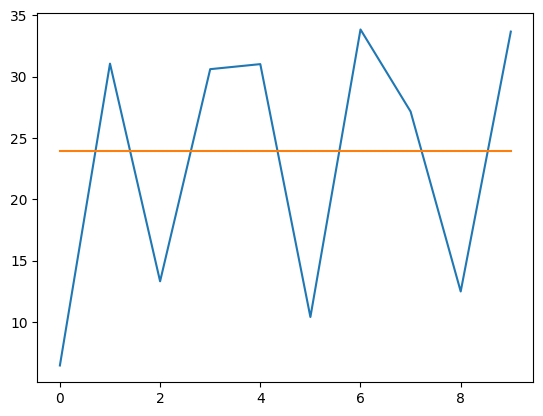

In [3]:
# A year with 15-minute intervals
alpha = 0.999
# T = int(35040/2)
# T = 2
T = 35000
# T = 10000

# Synthetic data
# rng = np.random.default_rng(2025)
# l_agg = 1.2 + 0.3*np.sin(np.linspace(0, 2*np.pi, T)) + 0.05*rng.normal(size=T)

l_agg = df['out.electricity.net.energy_consumption'][0:T].values
tstamps = df['timestamp'][0:T].values


# lhat = np.ones(T)
# lhat = np.arange(T)
lhat = np.sin(np.arange(T)/100) + 1
# lhat[0:10] = 0

p0 = 150   # transformer limit in MW
# K = 100     # number of curtailment slots allowed
K = round((1-alpha)*T)

# Residual capacity
c_res = p0 - l_agg

# Dynamic hosting capacity
c_dyn = np.full(T, np.inf)
active = lhat > 1e-12 # to avoid division by zero;
active_idx = np.flatnonzero(active)

c_dyn[active] = c_res[active] / lhat[active]

# Sort active slots by dynamic hosting capacity
sorted_active_local = np.argsort(c_dyn[active])          # indices within active subset
sorted_active_global = active_idx[sorted_active_local]   # map back to original timeline

# (K+1)-th smallest dynamic hosting capacity
C_k = c_dyn[sorted_active_global[K]]

# Intervene at the K slots of lowest dynamic hosting capacity
intervention_idx = sorted_active_global[:K]

u = np.zeros(T, dtype=float)
u[intervention_idx] = c_res[intervention_idx] - C_k * lhat[intervention_idx]

# print("C*_K =", C_k)
# print("Curtailments --")
# for idx in intervention_idx:  
#     print(f"t={idx:>5d}: u(t) = {u[idx]:.6f} MW")

## CVAR with no curtailment budget
## Ensuring the expected tail loss is below epsilon with confidence level alpha

# parameters
# alpha = 0.95
# alpha_opt = alpha
epsilon = 0

# Decision Variables
C = cp.Variable(name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, name="s")
u_CVaR = cp.Variable(T,name="u_CVaR")
t = cp.Variable(T,name="t")

eta_old = 0

# # c_res = p0 - l_agg
iters = 10
C_iters = np.zeros(iters)
u_CVaRs = np.zeros((iters,T))

for k in range(iters):

    eta_prev = eta_old

    constraints = [
        # C*lhat - u_CVaR + l_agg <= p0,
        C*lhat - u_CVaR + l_agg <= p0-eta_old,
        # C*lhat - u_CVaR + l_agg <= p0,
        # C*lhat - u_CVaR + l_agg <= p0-eta_old,
        # C*lhat - u_CVaR + l_agg <= p0-eta_old,
        # C*lhat + u + l_agg <= p0,
        eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
        # u_CVaR +eta_old - eta <= s,
        u_CVaR- eta <= s,
        0<= u_CVaR - eta,
        # u_CVaR - eta <= s,
        0<=s,
        # u_CVaR<=t,
        # 0<=t
        # 0<=u_CVaR +eta_old-eta
        # 0<=u_CVaR
        # u_CVaR >=0
        # C*lhat + l_agg <= p0,
        # eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
        # u_CVaR - eta <= s 
        # s >= C * lhat - c_res - eta,
        # eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    ]

    # constraints = [
    #     # C*lhat - u_CVaR + l_agg <= p0,
    #     # C*lhat - u_CVaR + l_agg <= p0-eta_old,
    #     # C*lhat - u_CVaR + l_agg <= p0,
    #     C*lhat - u_CVaR + l_agg <= p0,
    #     # C*lhat + u + l_agg <= p0,
    #     # eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
    #     # u_CVaR +eta_old - eta <= s,
    #     # # u_CVaR - eta <= s,
    #     # 0<=s,
    #     # # u_CVaR<=t,
    #     # # 0<=t
    #     # 0<=u_CVaR +eta_old-eta
    #     # 0<=u_CVaR
    #     # u_CVaR >=0
    #     # C*lhat + l_agg <= p0,
    #     # eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
    #     # u_CVaR - eta <= s 
    #     # s >= C * lhat - c_res - eta,
    #     # eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    #     0<= u_CVaR +eta_old- eta,
    #     (1/T)*cp.sum(u_CVaR+eta_old) == eta*alpha
    # ]

    # obj = cp.Maximize(C)
    obj = cp.Minimize(-C)
    problem = cp.Problem(obj, constraints)

    problem.solve(solver="ECOS", verbose=False)

    print("Optimal C:", C.value)
    print("C_K",C_k)

    C_iters[k] = C.value

    # eta_old = eta.value*0.2 + eta_old*0.8
    eta_old = eta.value

    u_CVaRs[k] = u_CVaR.value

    # print('K '+str(K))
    # print('CVaR K '+str(len(np.nonzero(np.maximum(u_CVaR.value,0))[0])))

    # print('eta: '+str(eta.value))
#     plt.figure(dpi=200)
# # plt.plot(p0 - l_agg,label='p0-l_agg')
# # plt.plot(p0 - l_agg+u_CVaR.value,label='p0-l_agg+u_CVaR')
#     plt.plot(p0 - l_agg+s.value,label='p0-l_agg+s')
#     plt.plot(p0 - l_agg-u,alpha=0.5,label='p0-l_agg-u')
#     plt.plot(lhat*C.value,label='C')
#     plt.plot(lhat*C_k,label='C_k')
#     plt.legend()
#     plt.title('eta = '+str(eta.value))

#     plt.figure(dpi=200)
# # plt.plot(p0 - l_agg,label='p0-l_agg')
# # plt.plot(p0 - l_agg+u_CVaR.value,label='p0-l_agg+u_CVaR')
#     plt.plot(p0 - l_agg+s.value,label='p0-l_agg+s')
#     plt.plot(p0 - l_agg-u,alpha=0.5,label='p0-l_agg-u')
#     plt.plot(lhat*C.value,label='C')
#     plt.plot(lhat*C_k,label='C_k')
#     plt.legend()
#     plt.title('eta = '+str(eta.value))

plt.plot(C_iters)
plt.plot(np.ones_like(C_iters)*C_k)    

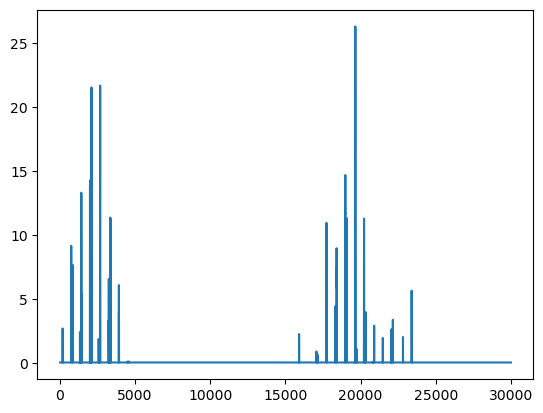

In [43]:
plt.plot(s.value)

(0.9, 1.0)

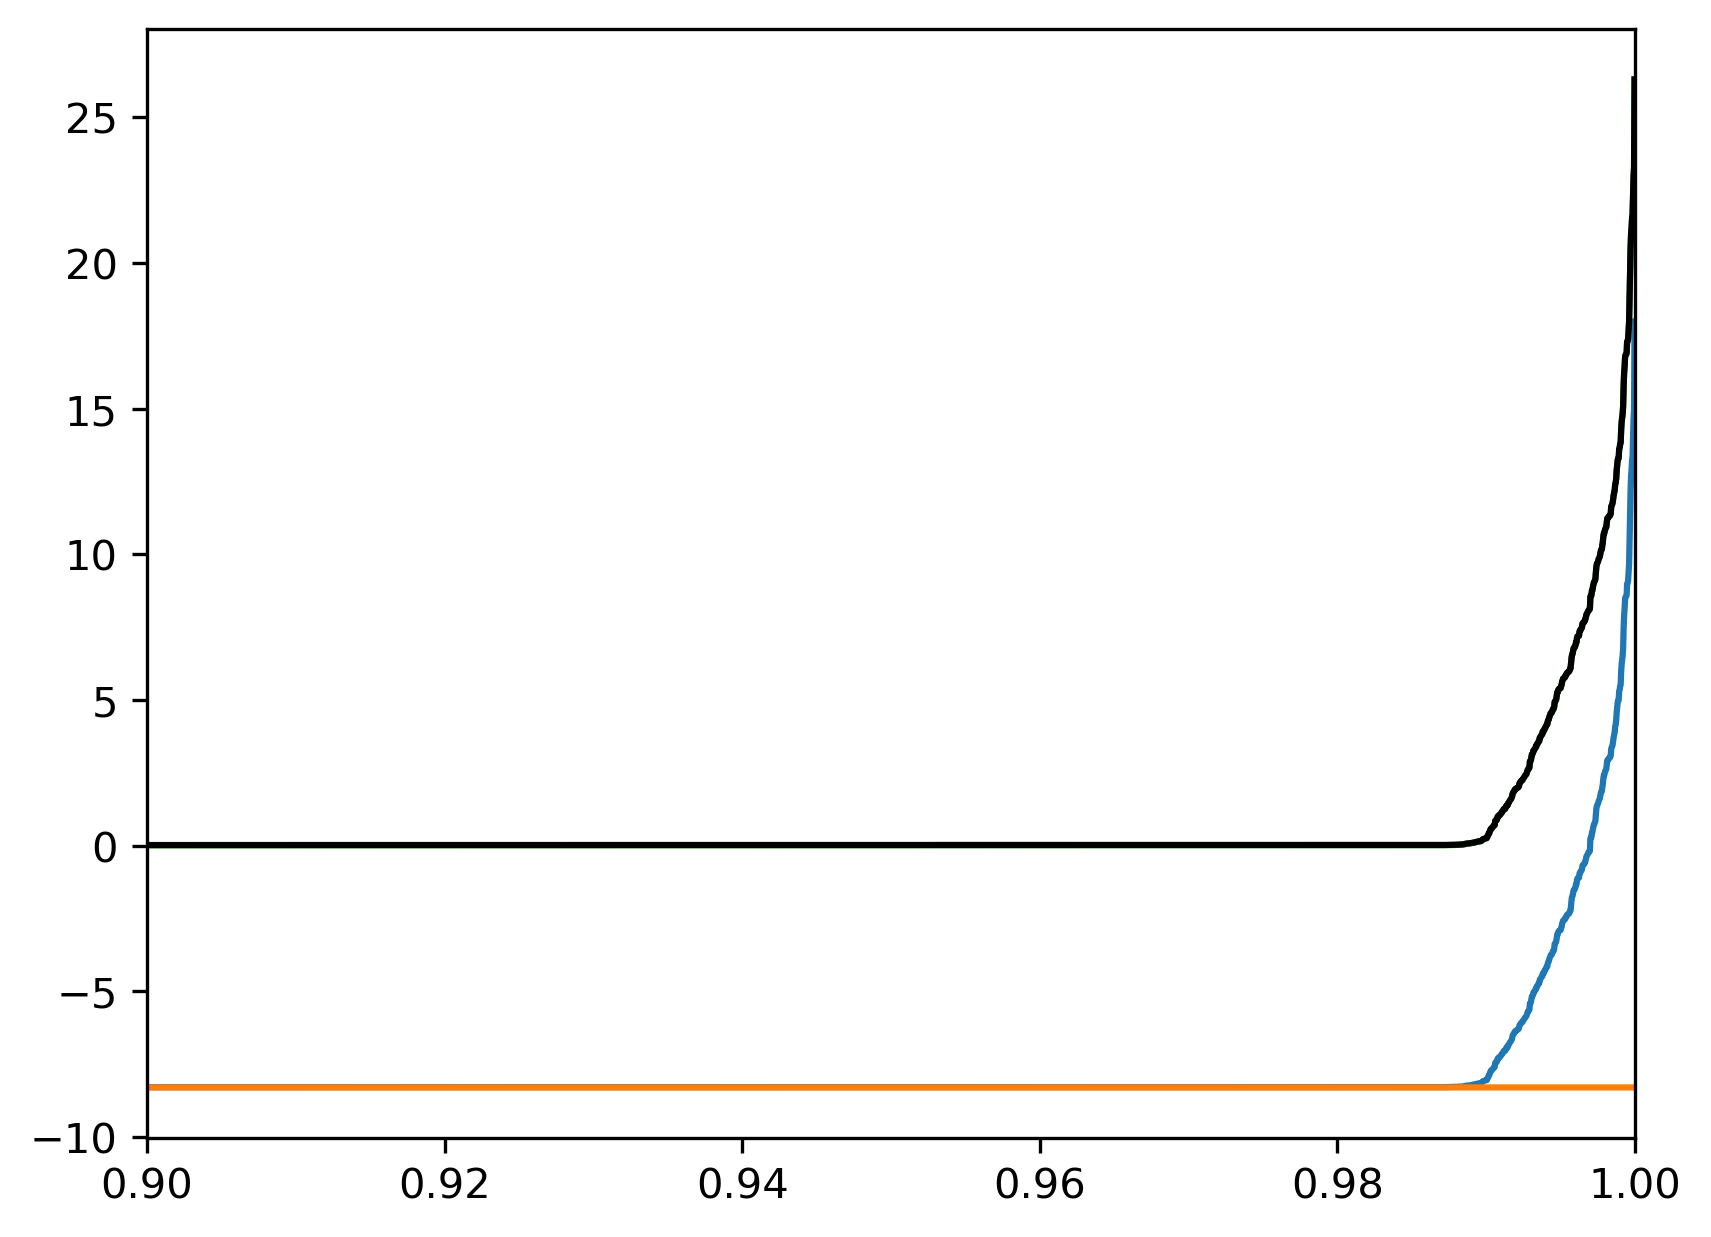

In [52]:
plt.figure(dpi=300)
plt.plot(np.arange(T)/T,np.sort(u_CVaR.value))
plt.plot(np.arange(T)/T,eta.value*np.ones_like(u_CVaR.value))
plt.plot(np.arange(T)/T,np.sort(u_CVaR.value)-eta.value)
plt.plot(np.arange(T)/T,np.sort(s.value),color='k')
plt.xlim([0.9,1.0])

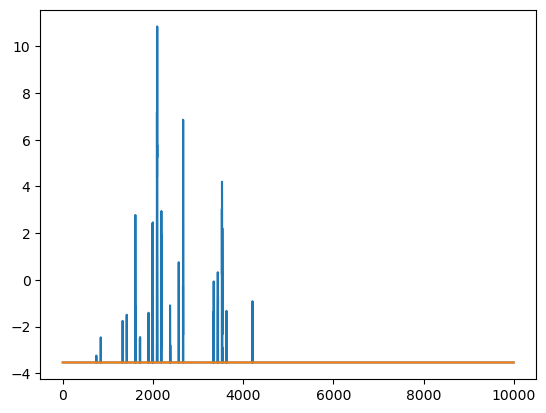

In [34]:
plt.plot(u_CVaR.value)
plt.plot(np.ones_like(u_CVaR.value)*eta.value)

In [33]:
eta.value

array(-3.53421877)

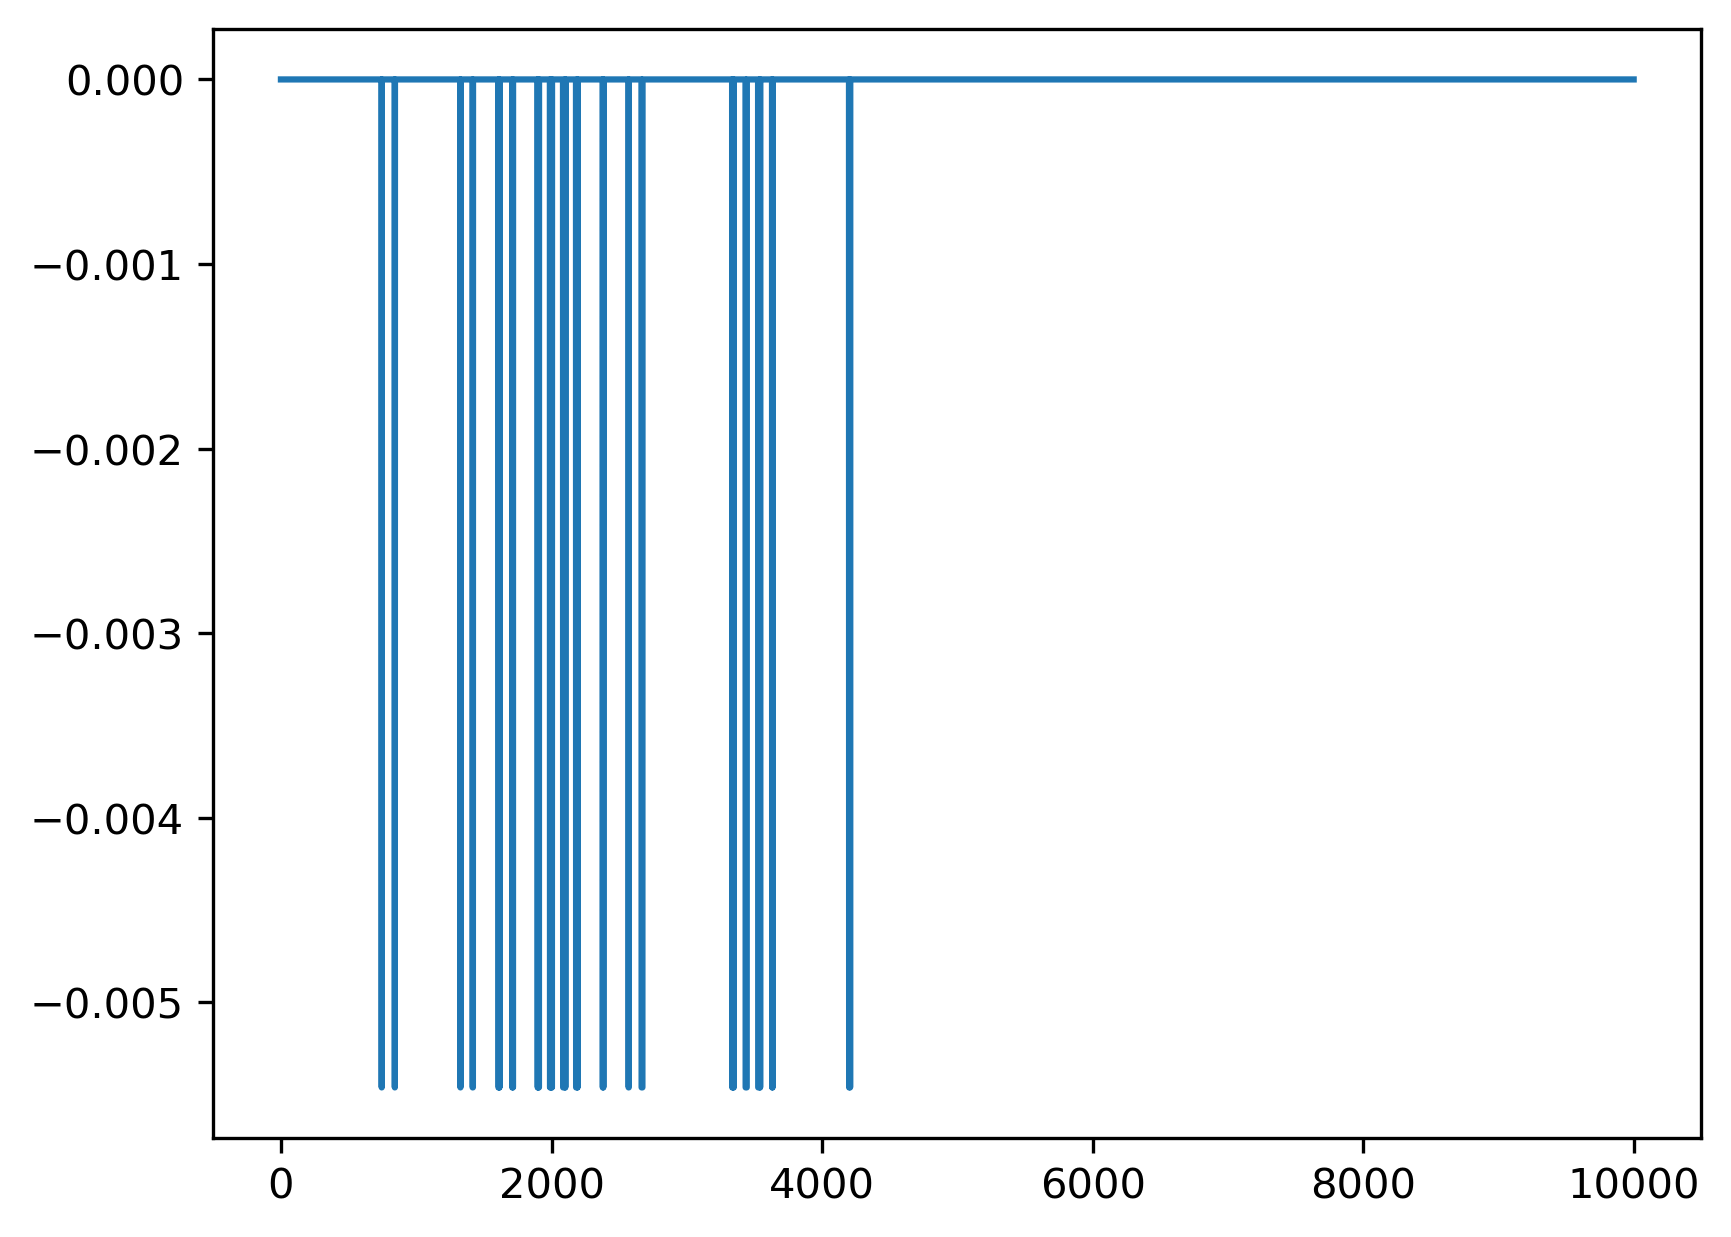

In [21]:
plt.figure(dpi=300)
# plt.plot(u) 
# plt.plot(-s.value)
plt.plot(u+s.value)

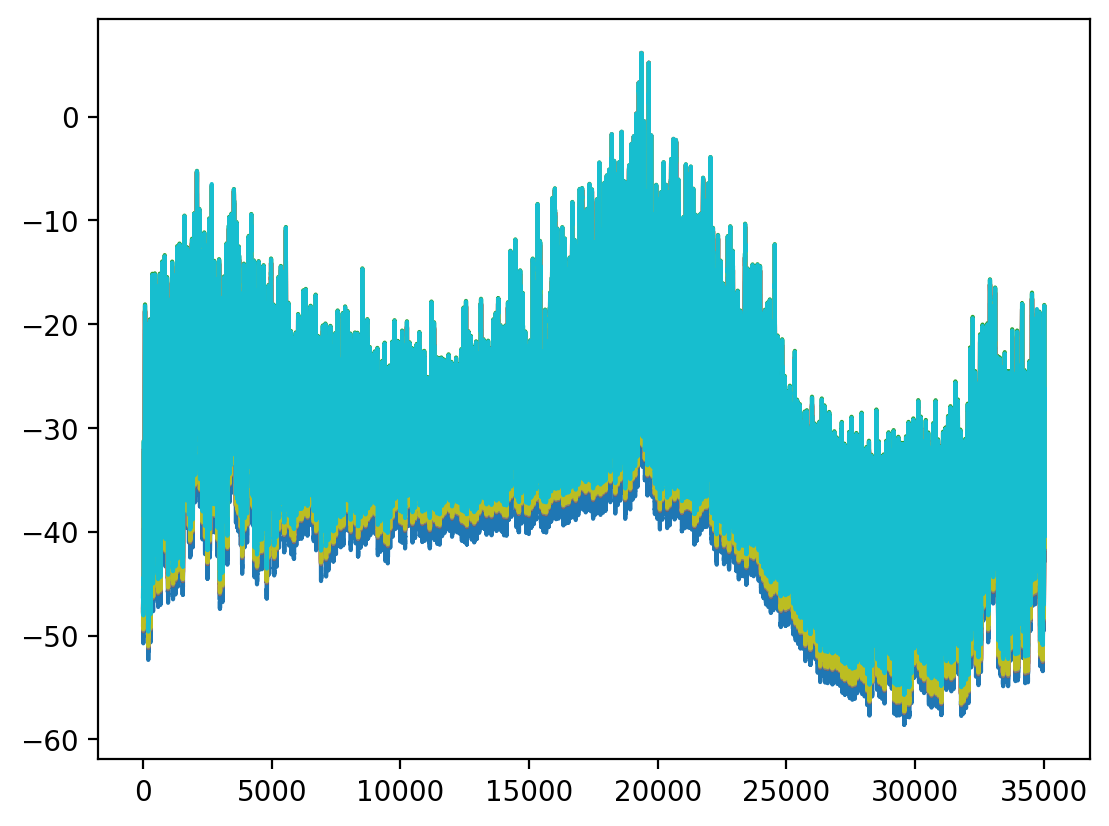

In [ ]:
plt.figure(dpi=200)
plt.plot(u_CVaRs.T)

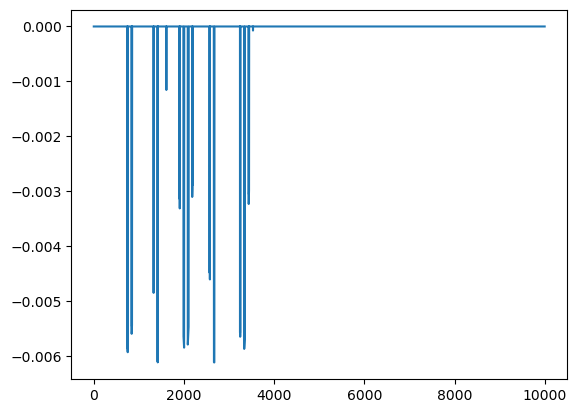

In [ ]:
# plt.plot(s.value)
plt.plot(s.value+u)

Text(0.5, 1.0, 'eta = -4.787705953048263')

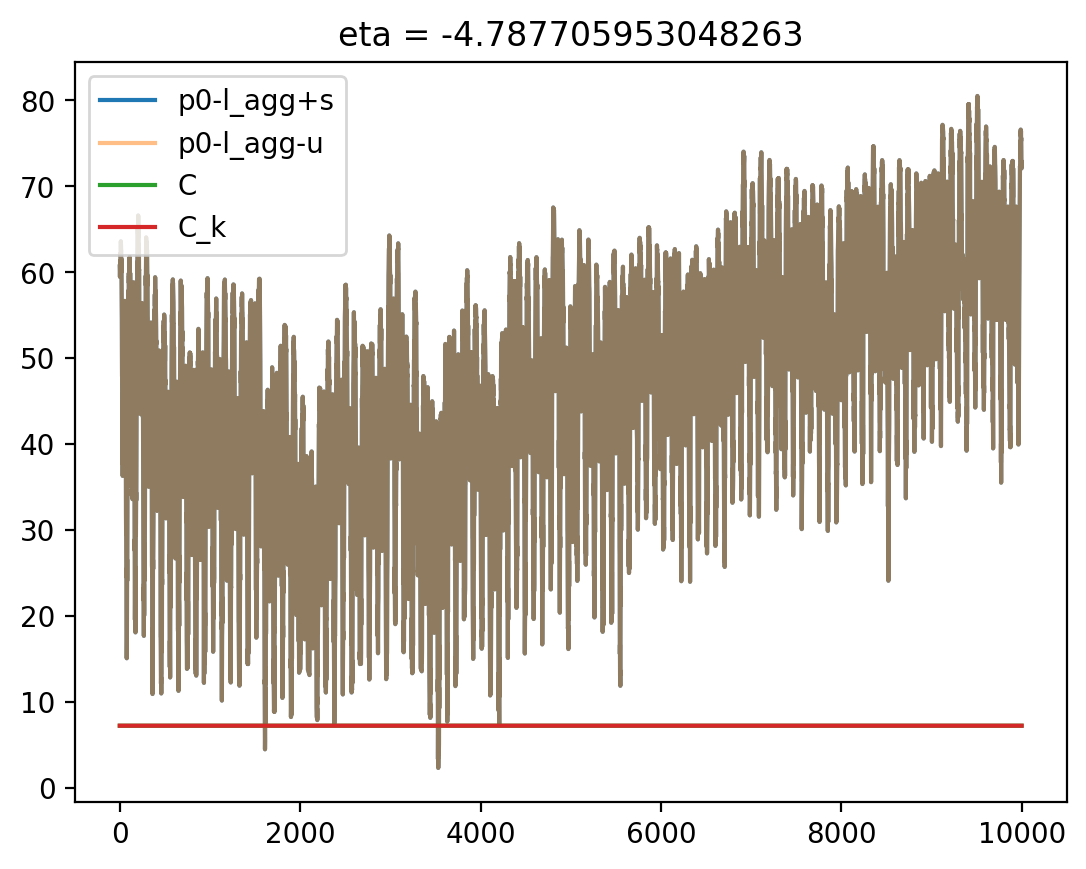

In [ ]:
plt.figure(dpi=200)
# plt.plot(p0 - l_agg,label='p0-l_agg')
# plt.plot(p0 - l_agg+u_CVaR.value,label='p0-l_agg+u_CVaR')
plt.plot(p0 - l_agg+s.value,label='p0-l_agg+s')
plt.plot(p0 - l_agg-u,alpha=0.5,label='p0-l_agg-u')
plt.plot(np.ones_like(l_agg)*C.value,label='C')
plt.plot(np.ones_like(l_agg)*C_k,label='C_k')
plt.legend()
plt.title('eta = '+str(eta.value))
# plt.ylim([10,30])
# plt.xlim([800,900])

-0.8461498838284884


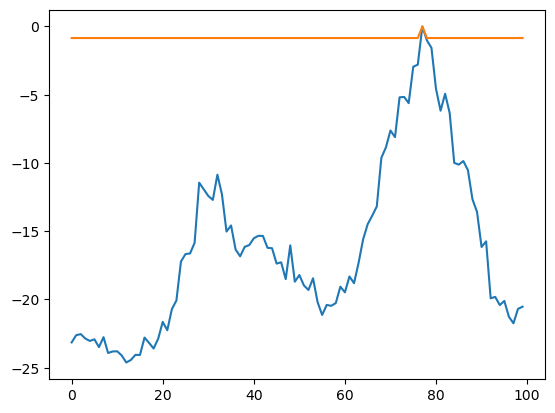

In [ ]:
plt.plot(u_CVaR.value)
plt.plot(eta.value+s.value)
print(eta.value)

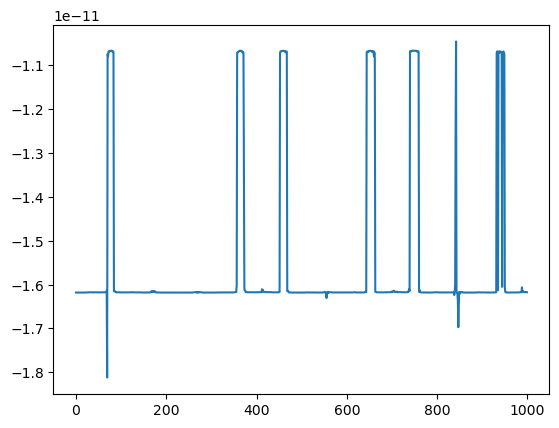

In [ ]:
# plt.plot(s.value)
plt.plot(u_CVaR.value-eta.value - s.value)

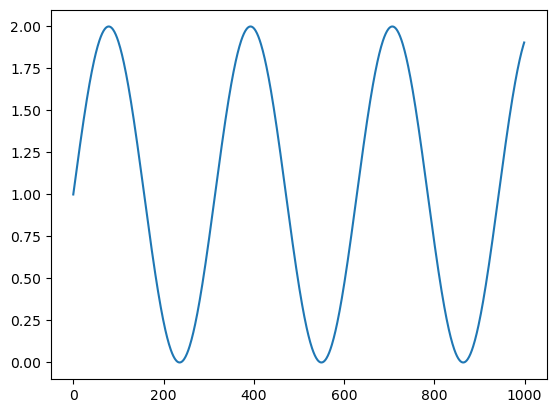

In [ ]:
plt.plot(lhat)

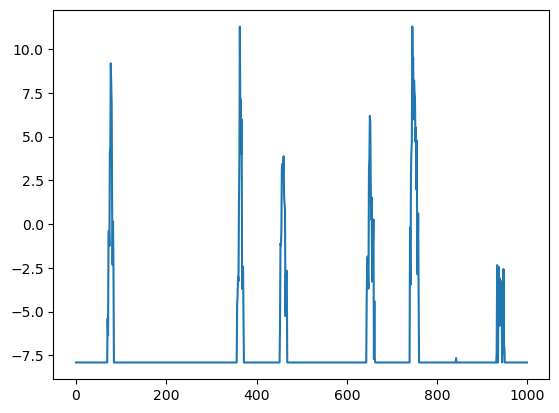

In [ ]:
plt.plot(u_CVaR.value)

In [ ]:
C_k - C.value

np.float64(5.195770000217333)

In [ ]:
eta_val = eta.value

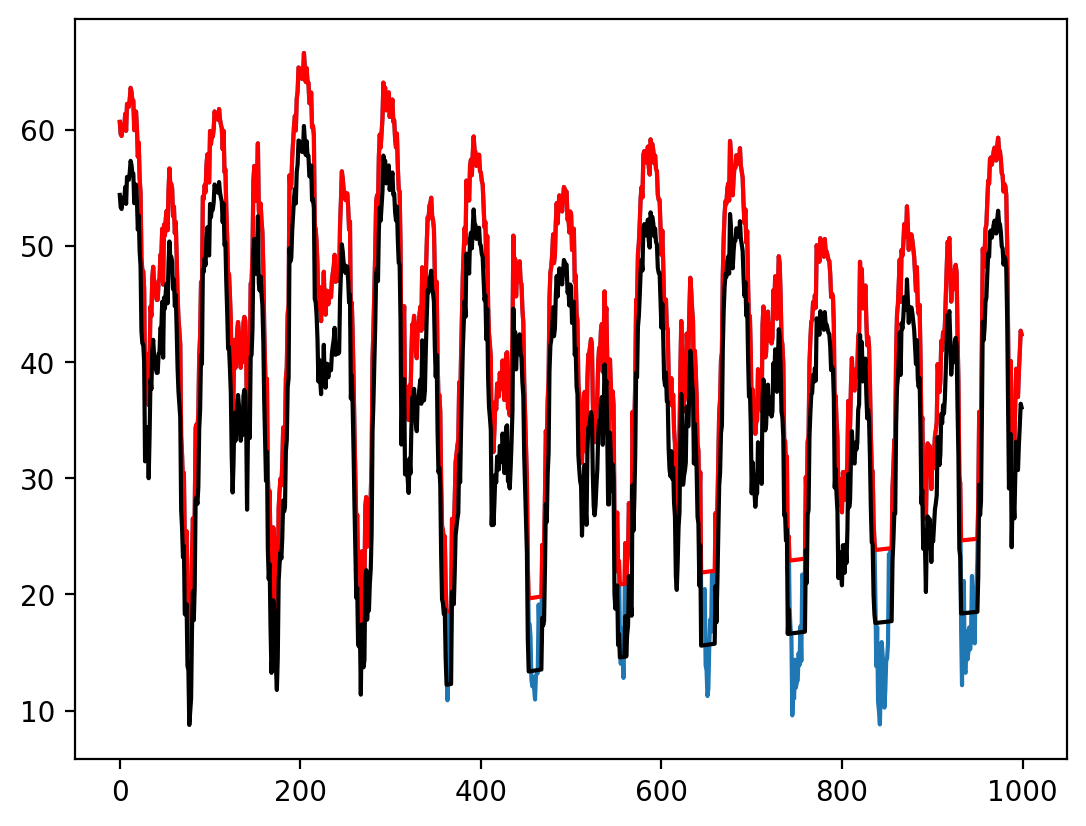

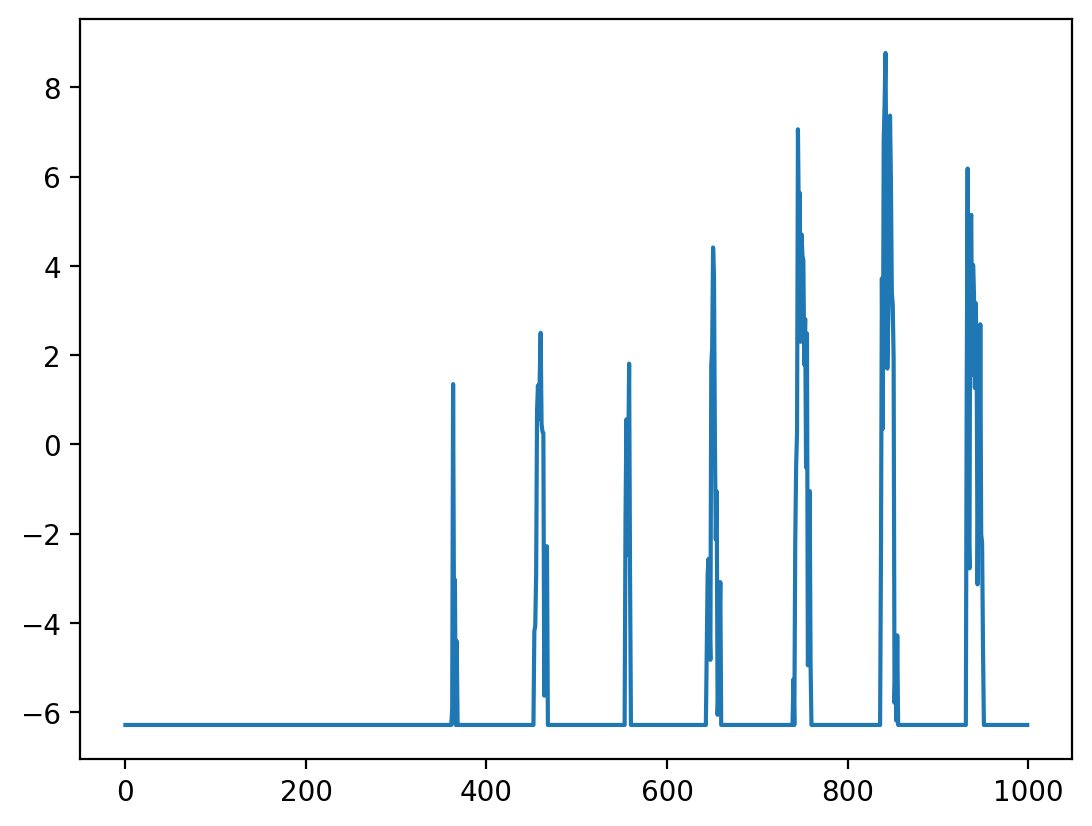

In [ ]:
plt.figure(dpi=200)
plt.plot((p0-l_agg))
plt.plot(p0-l_agg-u,color='r')
plt.plot((p0-l_agg+u_CVaR.value),color='k')

plt.figure(dpi=200)
plt.plot(u_CVaR.value)

(0.0, 200.0)

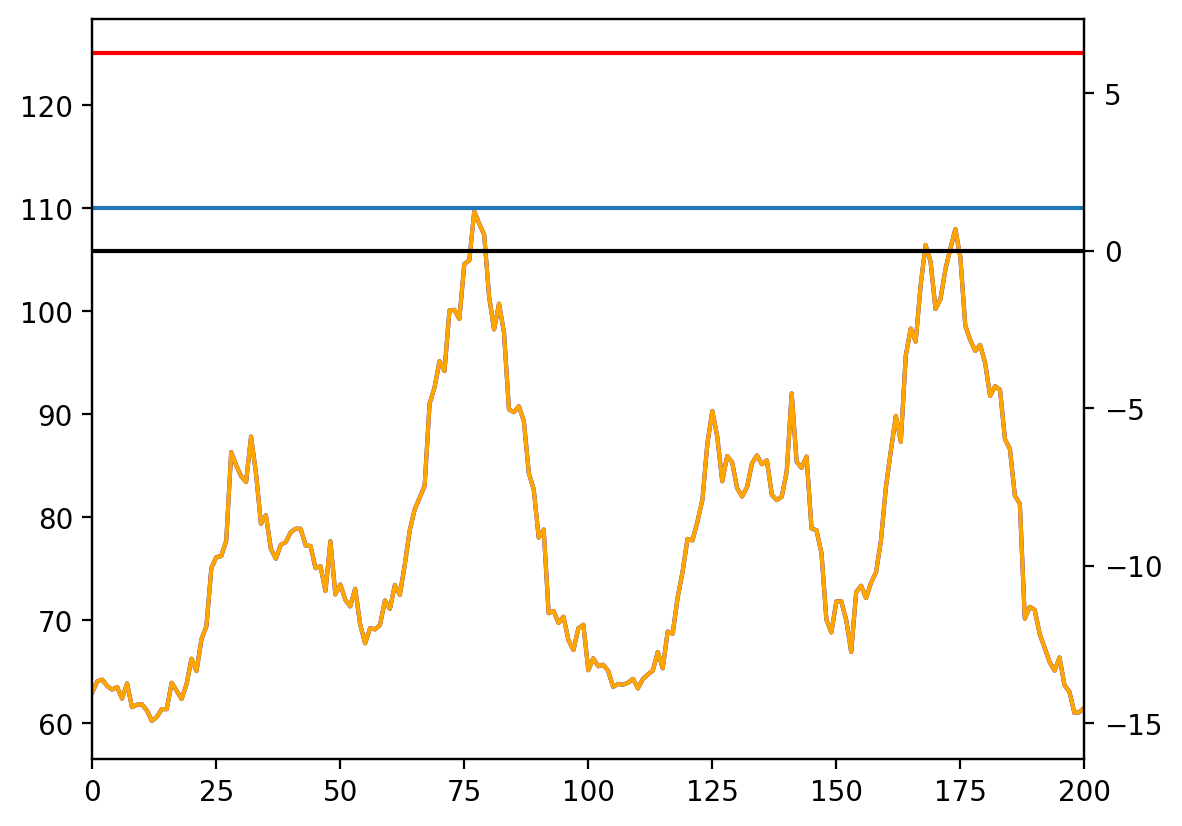

In [ ]:
plt.figure(dpi=200)
ax = plt.gca()
# plt.hlines(p0,0,T)
ax.plot(np.arange(0,T),C.value*lhat+l_agg,color='b')
ax.plot(np.arange(0,T),C_k*lhat+l_agg,color='orange')
ax.hlines(p0,0,T)
ax.set_xlim(0,200)
# plt.plot(np.arange(0,T),C.value*lhat + l_agg)
# plt.plot(np.arange(0,T),u_CVaR.value)
ax2 = ax.twinx()
ax2.plot(np.arange(0,T),-u_CVaR.value,color='r')
ax2.plot(np.arange(0,T),u,color='k')
ax2.set_xlim(0,200)

In [ ]:
eta.value

array(-5.04227082)

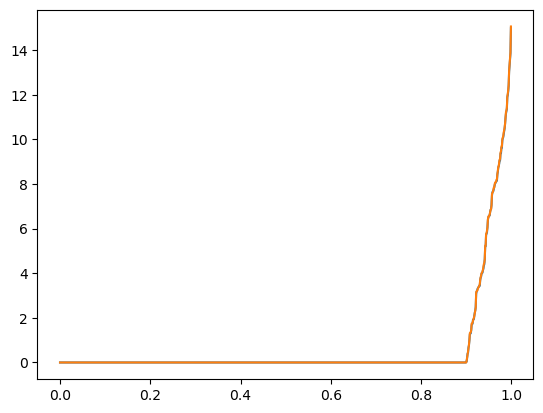

In [ ]:
# plt.plot(np.arange(T)/T,np.maximum(np.sort(u_CVaR.value)-eta.value,0))
plt.plot(np.arange(T)/T,np.sort(u_CVaR.value)-eta.value)
plt.plot(np.arange(T)/T,np.sort(-u))

In [ ]:
print(K)
print(len(np.nonzero(np.maximum(u_CVaR.value,0))[0]))

1752
1503


0.0
-37.02677376821066


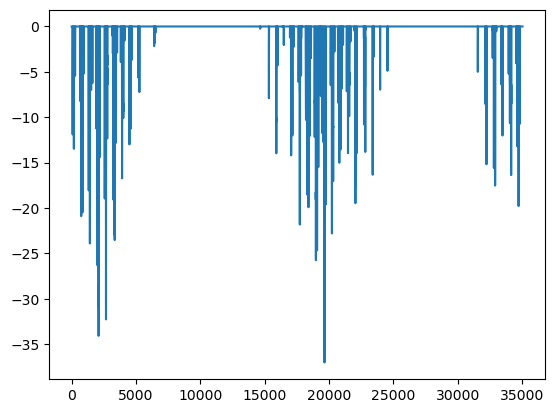

In [ ]:
plt.plot(u)
print(np.max(u))
print(np.min(u))

In [ ]:
len(np.nonzero(u)[0])

100

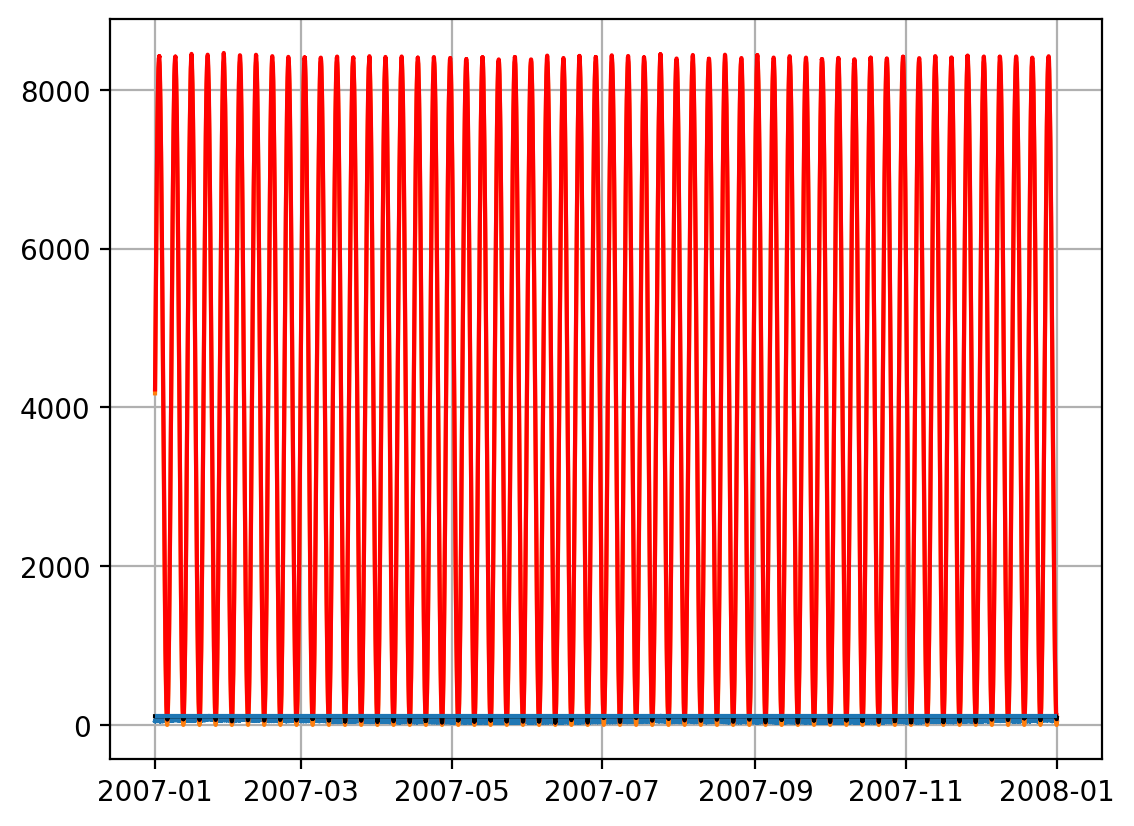

In [ ]:
plt.figure(dpi=200)
plt.plot(tstamps,l_agg)
plt.plot(tstamps,lhat*C_k)
plt.plot(tstamps,l_agg+C_k * lhat,'r')
plt.plot(tstamps,l_agg+C_k * lhat+u,'k')
plt.hlines(p0,tstamps[0],tstamps[-1])
plt.grid()

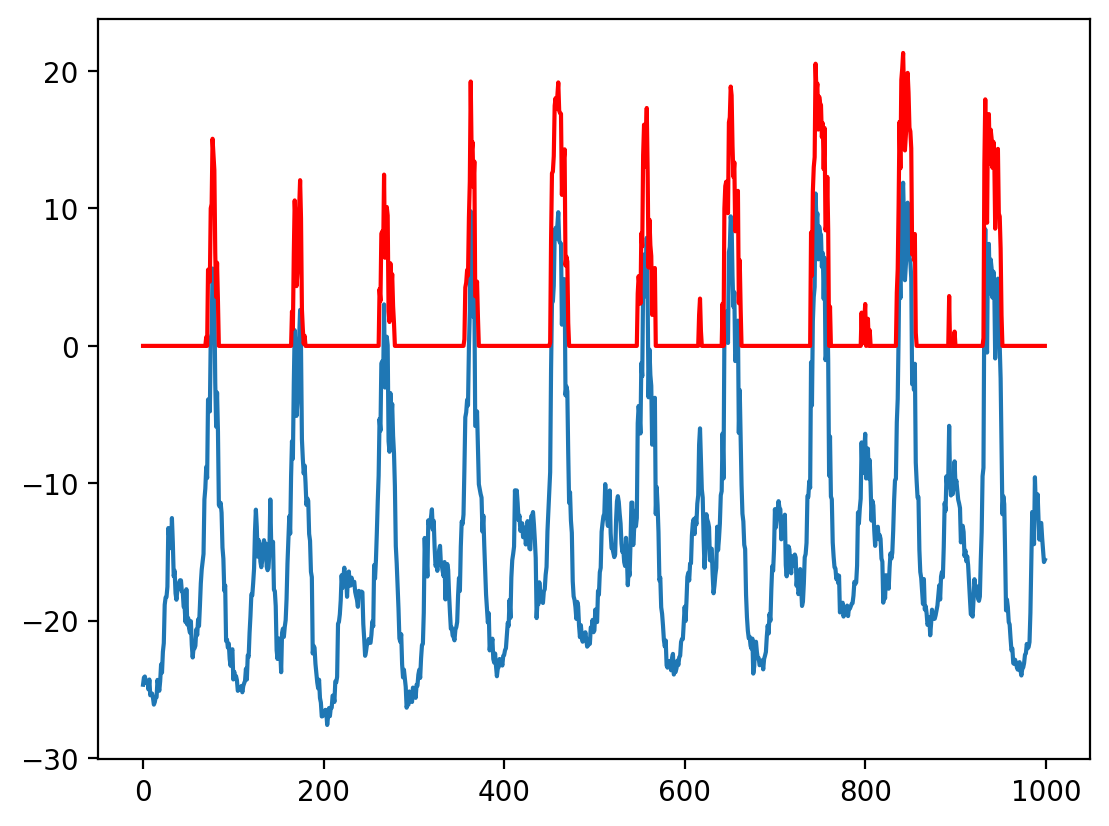

In [ ]:
plt.figure(dpi=200)
plt.plot(u_CVaR.value)
plt.plot(s.value,'r')

(0.0, 500.0)

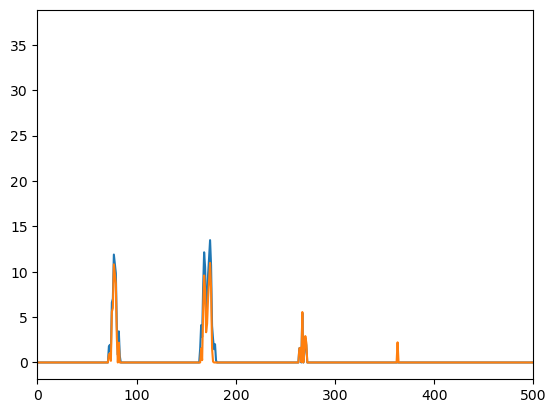

In [ ]:
u_CVaR_post = np.maximum(u_CVaR.value-eta.value,0)
plt.plot(-u)
plt.plot(u_CVaR_post)
plt.xlim([0,500])

In [ ]:
len(np.nonzero(u_CVaR_post)[0])

1752

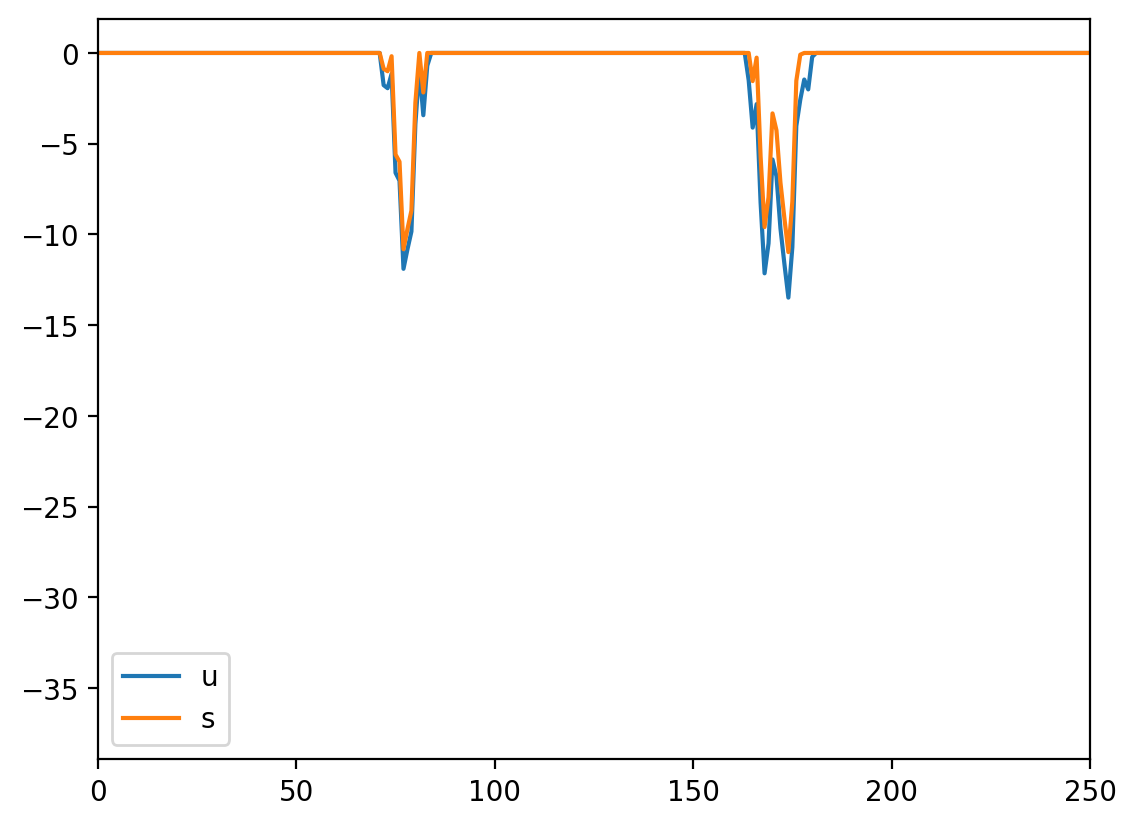

In [ ]:
plt.figure(dpi=200)
plt.plot(u,label='u')
plt.plot(-s.value,label='s')
plt.xlim(0,250)
plt.legend()

In [ ]:
## CVAR with no curtailment budget
## Ensuring the expected tail loss is below epsilon with confidence level alpha

# parameters
# alpha = 0.95
epsilon = 0

# Decision Variables
C = cp.Variable(name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, name="s")
u_CVaR = cp.Variable(T,name="u_CVaR")

# c_res = p0 - l_agg

constraints = [
    C*lhat - u_CVaR + l_agg <= p0,
    eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
    u_CVaR - eta <= s,
    0<=s
    # u_CVaR >=0
    # C*lhat + l_agg <= p0,
    # eta + (1.0 / ((1.0 - alpha) * T)) *cp.sum(s) <= 0,
    # u_CVaR - eta <= s 
    # s >= C * lhat - c_res - eta,
    # eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    
]

# obj = cp.Maximize(C)
obj = cp.Minimize(-C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal C:", C.value)
print("C_K",C_k)

(CVXPY) Mar 29 12:56:10 AM: Your problem has 70082 variables, 105121 constraints, and 0 parameters.
(CVXPY) Mar 29 12:56:10 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 29 12:56:10 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 29 12:56:10 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 29 12:56:10 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 29 12:56:10 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 29 12:56:10 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 29 12:56:10 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 29 12:56:10 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 29 12:56:10 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 29 12:56:10 AM: Applying reduction ECOS
(CVXPY) Mar 29 12:56:10 AM: Finished problem compilation (

                                     CVXPY                                     
                                     v1.8.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------

ECOS 2.0.10 - (C) embotech GmbH, Zurich Switzerland, 2012-15. Web: www.embotech.com/ECOS

It     pcost       dcost      gap   pres   dres    k/t    mu     step   sigma     IR    |   BT
 0  -4.802e-03  -1.689e+06  +2e+06  3e-01  1e+02  1e+00  2e+01    ---    ---    2  1  - |  -  - 
 1  +7.218e-01  -1.832e+06  +2e+06  3e-01  2e+02  7e+00  2e+01  0.3460  6e-01

(CVXPY) Mar 29 12:56:11 AM: Problem status: optimal
(CVXPY) Mar 29 12:56:11 AM: Optimal value: -1.095e+01
(CVXPY) Mar 29 12:56:11 AM: Compilation took 1.209e-01 seconds
(CVXPY) Mar 29 12:56:11 AM: Solver (including time spent in interface) took 9.195e-01 seconds


43  -1.095e+01  -1.095e+01  +4e-08  2e-15  1e-10  8e-14  3e-13  0.9890  1e-04   1  0  0 |  0  0

OPTIMAL (within feastol=1.2e-10, reltol=3.4e-09, abstol=3.7e-08).-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

Runtime: 0.916397 seconds.

Optimal C: 10.950588049183219
C_K 15.884879612201289


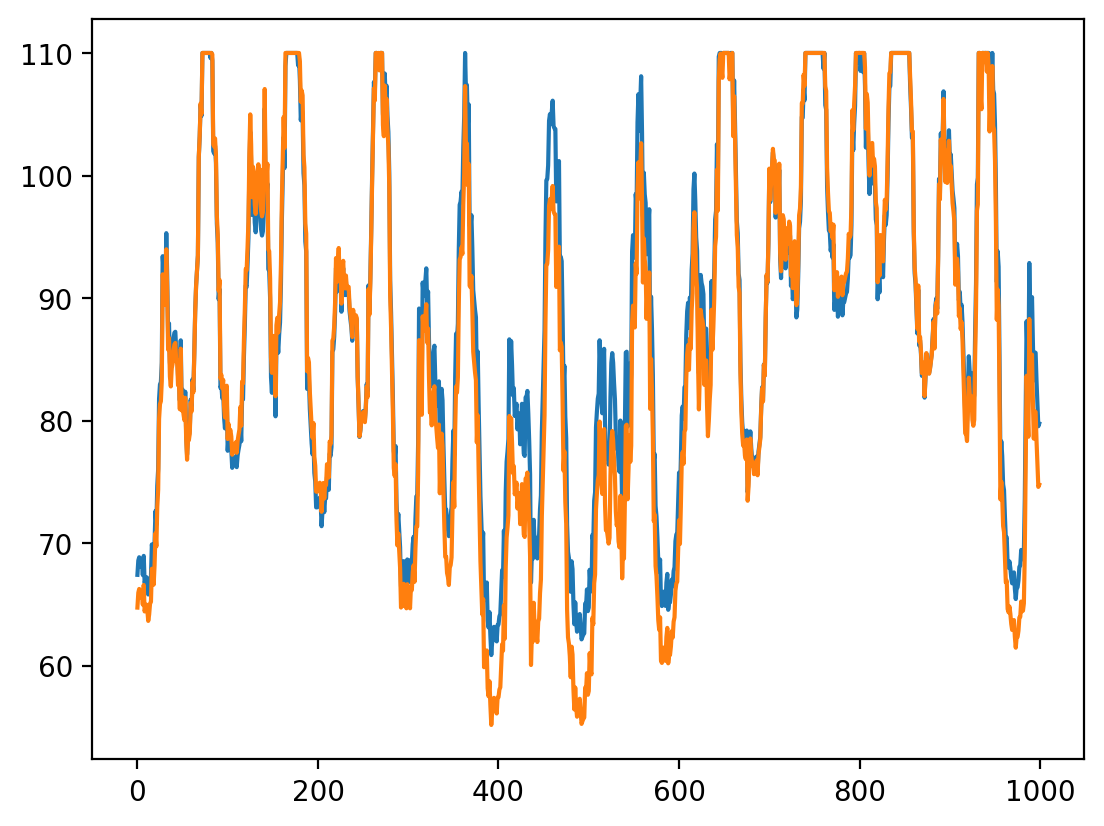

In [ ]:
plt.figure(dpi=200)
plt.plot(C.value*lhat - (eta.value + s.value)+ l_agg)
plt.plot(C_k*lhat + u + l_agg)

(500.0, 1000.0)

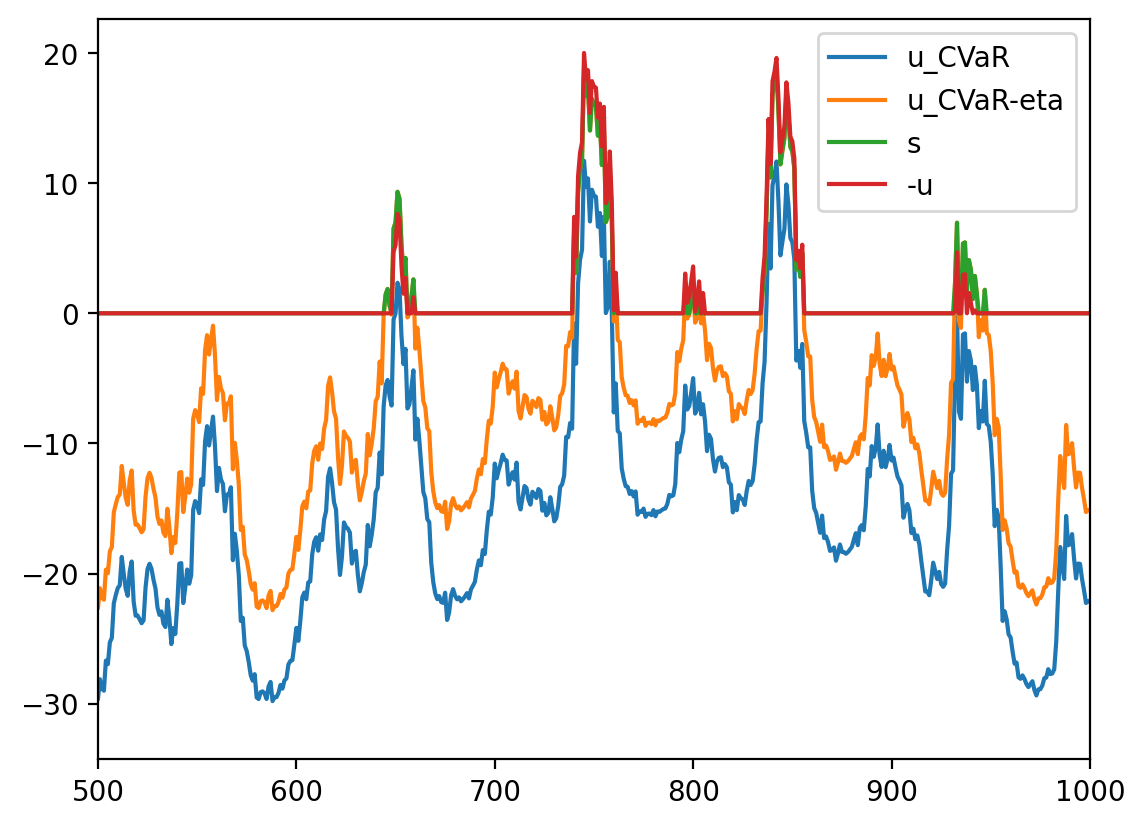

In [ ]:
plt.figure(dpi=200)
plt.plot(u_CVaR.value,label='u_CVaR')
plt.plot(u_CVaR.value-eta.value,label='u_CVaR-eta')
plt.plot(s.value,label='s')
plt.plot(-u,label='-u')
plt.legend()
plt.xlim([500,1000])

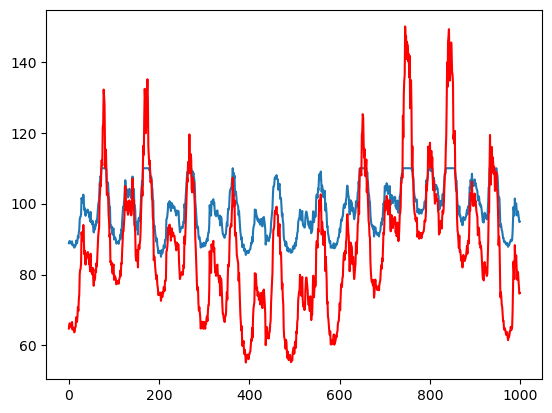

In [ ]:
plt.plot(C.value*lhat - u_CVaR.value + l_agg)
plt.plot(C_k*lhat -u + l_agg,'r')

In [ ]:
lambdas = constraints[0].dual_value
theta = constraints[1].dual_value
mus = constraints[2].dual_value
nus = constraints[3].dual_value

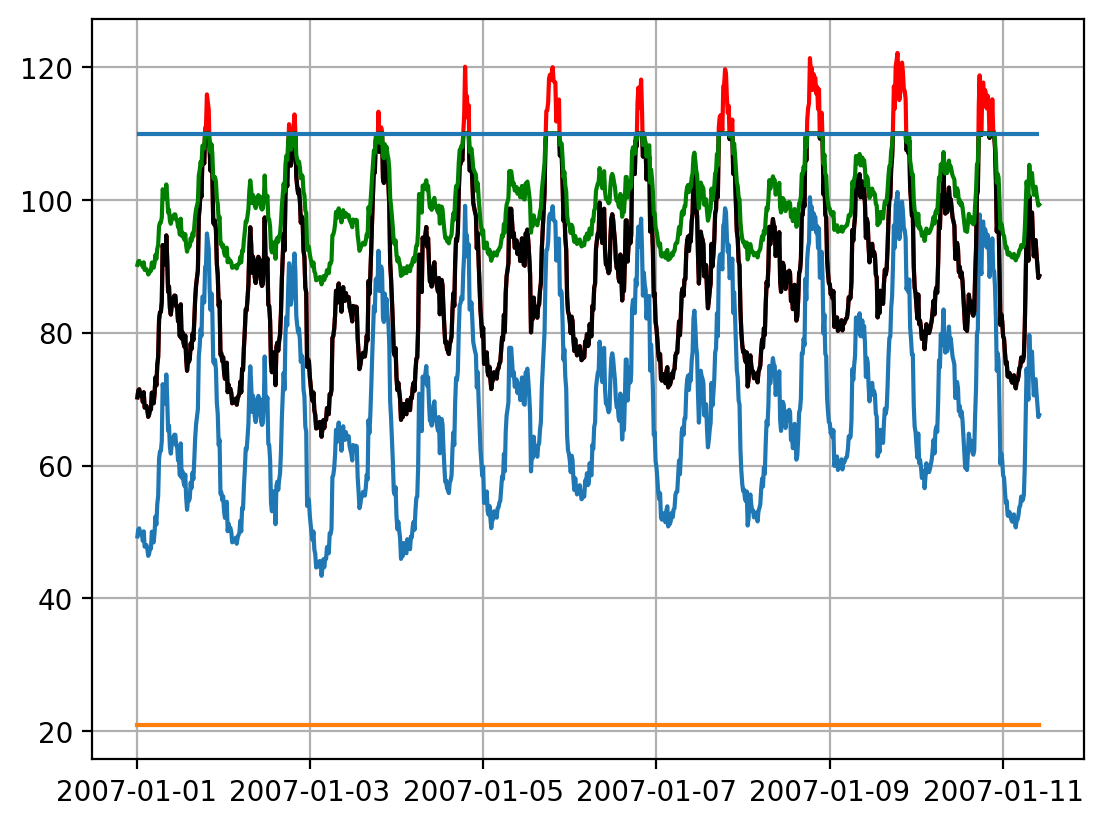

In [ ]:
plt.figure(dpi=200)
plt.plot(tstamps,l_agg)
plt.plot(tstamps,lhat*C_k)
plt.plot(tstamps,l_agg+C_k * lhat,'r')
plt.plot(tstamps,l_agg+C_k * lhat+u,'k')
plt.plot(tstamps,C.value*lhat + u_CVaR.value + l_agg,'g')
# plt.plot(tstamps,C.value*lhat - l_agg,'g')
plt.hlines(p0,tstamps[0],tstamps[-1])
plt.grid()

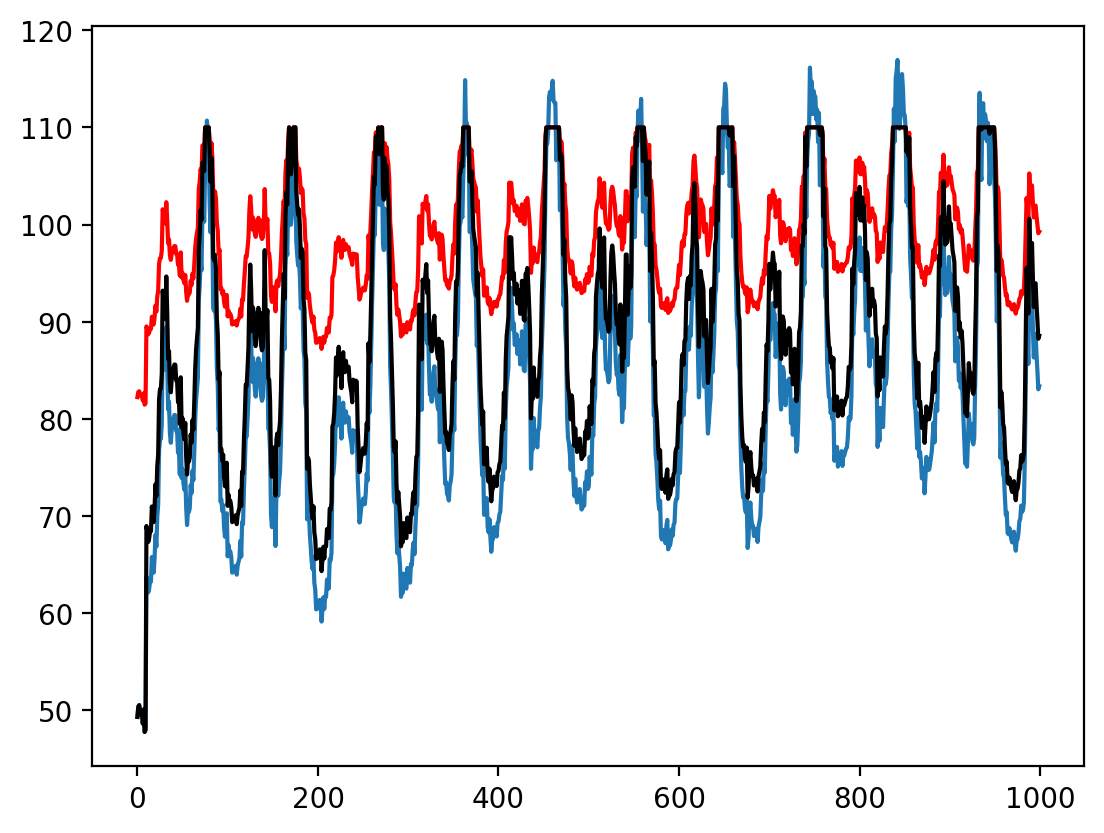

In [ ]:
plt.figure(dpi=200)
plt.plot(C.value*lhat + l_agg)
plt.plot(C.value*lhat - u_CVaR.value + l_agg,'r')
plt.plot(C_k*lhat + u + l_agg,'k')